<a href="https://colab.research.google.com/github/dmontelo7/Repositorio-2095700/blob/main/AF7_RNP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Actividad Fundamental 7: Redes Neuronales Artificiales
# Integrantes:
# Héctor Gerardo Quiñones Romo 2132258 IMC
# Diego Montelongo García 2095700 IMC
# Jesús Gael García Iracheta 2173941 IMC
# Lizbeth Águila Carvajal 2092193 IMC
# María Alejandra López Hernández 2177935 IMC
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.utils import to_categorical
import numpy as np
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [2]:
# 1. Cargar el conjunto de datos MNIST
(train_data, train_labels), (test_data, test_labels) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
# 2. Normalizar las imágenes (escalar valores de píxeles entre 0 y 1)
train_data = train_data / 255.0
test_data = test_data / 255.0

# 3. One-hot encoding de las etiquetas
train_labels_cat = to_categorical(train_labels, num_classes=10)
test_labels_cat = to_categorical(test_labels, num_classes=10)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9200 - loss: 0.2689 - val_accuracy: 0.9603 - val_loss: 0.1324
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9660 - loss: 0.1102 - val_accuracy: 0.9653 - val_loss: 0.1133
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9767 - loss: 0.0755 - val_accuracy: 0.9670 - val_loss: 0.1023
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9821 - loss: 0.0564 - val_accuracy: 0.9697 - val_loss: 0.1016
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9865 - loss: 0.0423 - val_accuracy: 0.9718 - val_loss: 0.0964
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9888 - loss: 0.0353 - val_accuracy: 0.9728 - val_loss: 0.1063
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9902 - loss: 0.0282 - val_accuracy: 0.9776 - val_loss: 0.0893
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9920 - loss: 0.0235 -

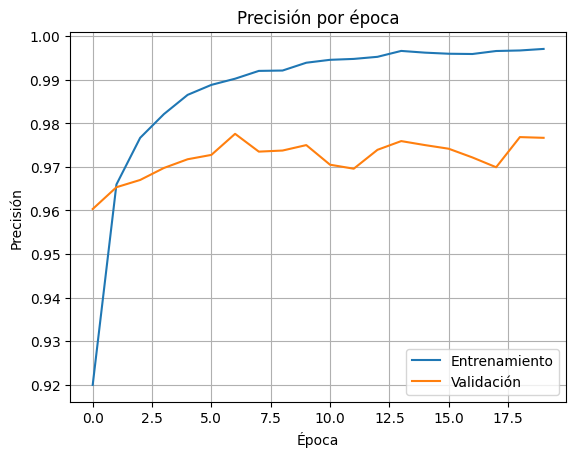

In [4]:
# 4. Definir el modelo (red neuronal artificial prealimentada)
modelo = Sequential([
    Flatten(input_shape=(28, 28)), # Aplanar la imagen de entrada
    Dense(128, activation='relu'), # Capa oculta con 128 neuronas
    Dense(64, activation='relu'), # Otra capa oculta con 64 neuronas
    Dense(10, activation='softmax') # Capa de salida para 10 clases
    ])

# 5. Compilar el modelo
modelo.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 6. Entrenar el modelo
history = modelo.fit(train_data, train_labels_cat, epochs=20, validation_split=0.2, batch_size=32)

# 7. Evaluar el modelo en el conjunto de prueba
test_loss, test_accuracy = modelo.evaluate(test_data, test_labels_cat)
print(f"Exactitud en el conjunto de prueba: {test_accuracy:.4f}")

# 8. Guardar el modelo en formato .keras
modelo.save("modelo_mnist.keras")

# 9. Graficar precisión por época
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.title('Precisión por época')
plt.legend()
plt.grid()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step

🖼️ Imagen #1
✔️ Valor real: 7
🪄 Predicción: 7


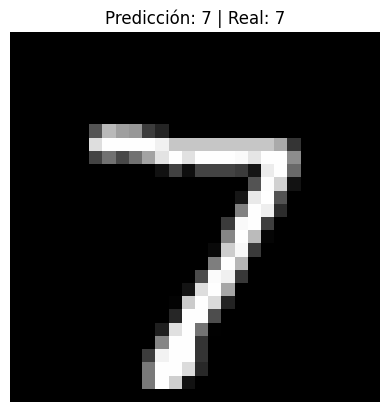

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step

🖼️ Imagen #2
✔️ Valor real: 2
🪄 Predicción: 2


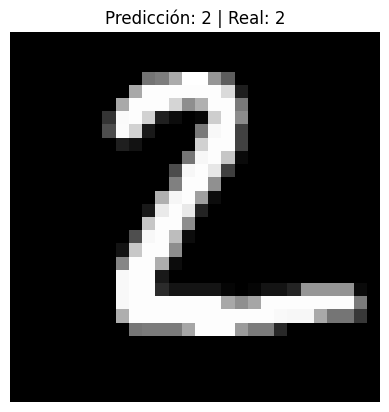

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

🖼️ Imagen #3
✔️ Valor real: 1
🪄 Predicción: 1


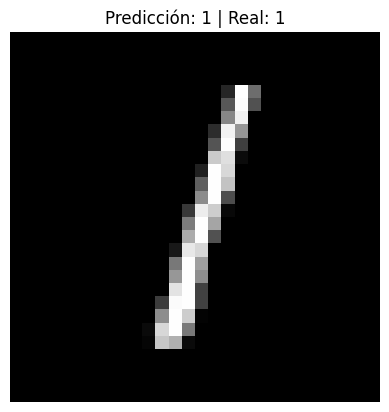

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

🖼️ Imagen #4
✔️ Valor real: 0
🪄 Predicción: 0


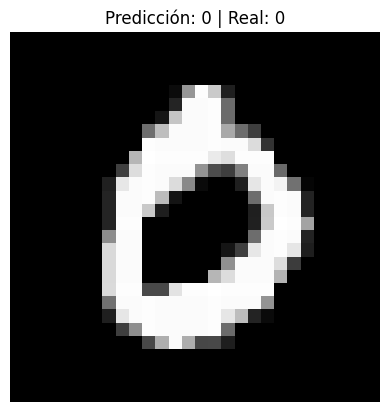

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step

🖼️ Imagen #5
✔️ Valor real: 4
🪄 Predicción: 4


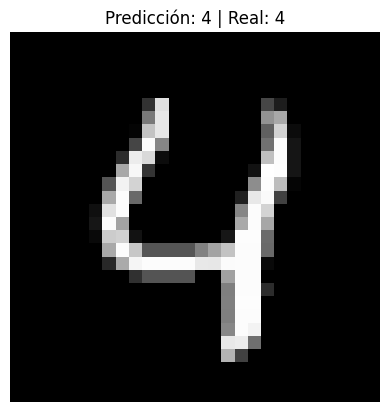

In [5]:
# 10. Cargar modelo .keras
modelo = tf.keras.models.load_model("modelo_mnist.keras")

# 11. Cargar datos de prueba
(_, _), (test_data, test_labels) = mnist.load_data()

# 12. Normalizar imágenes (escala de 0 a 1)
test_data = test_data / 255.0

# 13. Expandir dimensiones para incluir canal (28, 28) ---> (28, 28, 1)
test_data = np.expand_dims(test_data, axis=-1)

# 14. Realizar 5 predicciones
for i in range(5):
  imagen = test_data[i:i+1] # Imágen con batch size 1
  etiqueta_real = test_labels[i]

  pred = modelo.predict(imagen)
  clase_predicha = np.argmax(pred)

  # 15. Mostrar resultados
  print(f"\n🖼️ Imagen #{i+1}")
  print(f"✔️ Valor real: {etiqueta_real}")
  print(f"🪄 Predicción: {clase_predicha}")

  plt.imshow(np.squeeze(imagen), cmap='gray')
  plt.title(f"Predicción: {clase_predicha} | Real: {etiqueta_real}")
  plt.axis('off')
  plt.show()